# 02 — RAG Index Builder (V6)

Builds two FAISS indexes from compliance docs and pushes to HuggingFace.

**What's different from the old index:**
- Embedding model: `all-MiniLM-L6-v2` (not DistilBERT classifier encoder)
- CrossEncoder: `BAAI/bge-reranker-base` (better doc reranking)
- Weak classes get more chunks: Customer Service, General Inquiry, Human Resources,
  Returns and Exchanges, Sales — these had low F1 in V6 so RAG needs richer signal
- Each chunk stores `raw_body` (what gets shown to LLM) and `text` (what gets embedded)
- Priority index: 3 chunks (HIGH / MEDIUM / LOW sections) — unchanged

**Output files pushed to HF:**
- `rag_compliance_index.faiss`
- `rag_compliance_metadata.pkl`
- `rag_bm25_index.pkl`
- `rag_priority_index.faiss`
- `rag_priority_metadata.pkl`

## 0. Imports

In [1]:
import os
import re
import pickle
import numpy as np
import faiss
from pathlib import Path
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

load_dotenv('secrets.env')
HF_TOKEN = os.getenv('HF_TOKEN')

COMPLIANCE_DIR = Path('./compliance_docs')
RAG_REPO_ID    = 'Nethra19/rag-index-v6'

print(f'Token loaded: {HF_TOKEN[:8]}...')
print(f'Compliance docs dir: {COMPLIANCE_DIR.resolve()}')
print(f'Files found: {[f.name for f in COMPLIANCE_DIR.glob("*.txt")]}')

Token loaded: hf_nqjhQ...
Compliance docs dir: C:\Users\nethr\UCD Spring\ML\Project\New_trial\compliance_docs
Files found: ['Billing_and_Payments.txt', 'Customer_Service.txt', 'General_Inquiry.txt', 'Human_Resources.txt', 'Priority_Escalation_Criteria.txt', 'Returns_and_Exchanges.txt', 'Sales_and_Pre-Sales.txt', 'Service_Outages_and_Maintenance.txt', 'Technical___IT_Support.txt']


## 1. Create HF Repo (run once)

In [2]:
from huggingface_hub import HfApi

api = HfApi()

try:
    api.create_repo(
        repo_id=RAG_REPO_ID,
        repo_type='model',
        token=HF_TOKEN,
        exist_ok=True,       # no error if already exists
    )
    print(f'Repo ready: https://huggingface.co/{RAG_REPO_ID}')
except Exception as e:
    print(f'Repo creation note: {e}')

Repo ready: https://huggingface.co/Nethra19/rag-index-v6


## 2. Define Chunking Strategy

Each compliance doc has clear sections separated by blank lines.
We extract sections individually as chunks.

**Weak classes get extra synthetic example chunks** derived from the
REPRESENTATIVE EXAMPLES section — each example becomes its own chunk.
This gives RAG more surface area to match against for classes where
the transformer has low confidence (F1 < 0.70).

In [3]:
# V6 per-class F1 from test set — determines chunking strategy
# Classes below 0.70 F1 are "weak" and get extra example chunks
DEPT_F1 = {
    'Billing and Payments':            0.99,  # strong — standard chunking
    'Customer Service':                0.60,  # weak   — extra chunks
    'General Inquiry':                 0.64,  # weak   — extra chunks
    'Human Resources':                 0.65,  # weak   — extra chunks
    'Returns and Exchanges':           0.68,  # weak   — extra chunks
    'Sales and Pre-Sales':             0.71,  # borderline — extra chunks
    'Service Outages and Maintenance': 0.76,  # strong — standard chunking
    'Technical & IT Support':          0.78,  # strong — standard chunking
}

WEAK_THRESHOLD = 0.72  # below this F1 = add extra example chunks

# Map filename → department name
DEPT_FILE_MAP = {
    'Billing_and_Payments.txt':            'Billing and Payments',
    'Customer_Service.txt':                'Customer Service',
    'General_Inquiry.txt':                 'General Inquiry',
    'Human_Resources.txt':                 'Human Resources',
    'Returns_and_Exchanges.txt':           'Returns and Exchanges',
    'Sales_and_Pre-Sales.txt':             'Sales and Pre-Sales',
    'Service_Outages_and_Maintenance.txt': 'Service Outages and Maintenance',
    'Technical___IT_Support.txt':          'Technical & IT Support',
}

print('Dept → weak class?')
for dept, f1 in sorted(DEPT_F1.items(), key=lambda x: x[1]):
    weak = '⚠ WEAK — extra chunks' if f1 < WEAK_THRESHOLD else '✓ standard'
    print(f'  {dept:<40} F1={f1:.2f}  {weak}')

Dept → weak class?
  Customer Service                         F1=0.60  ⚠ WEAK — extra chunks
  General Inquiry                          F1=0.64  ⚠ WEAK — extra chunks
  Human Resources                          F1=0.65  ⚠ WEAK — extra chunks
  Returns and Exchanges                    F1=0.68  ⚠ WEAK — extra chunks
  Sales and Pre-Sales                      F1=0.71  ⚠ WEAK — extra chunks
  Service Outages and Maintenance          F1=0.76  ✓ standard
  Technical & IT Support                   F1=0.78  ✓ standard
  Billing and Payments                     F1=0.99  ✓ standard


## 3. Parse Compliance Docs into Chunks

In [4]:
def parse_doc_into_chunks(filepath: Path, dept_name: str, is_weak: bool) -> list:
    """
    Parse a compliance doc into chunks.

    Every doc gets:
      - 1 overview chunk (OVERVIEW section)
      - 1 routing guidance chunk (ROUTING DECISION GUIDANCE section)
      - 1 priority guidance chunk (PRIORITY GUIDANCE section)
      - 1 full-doc chunk (entire doc as context)

    Weak class docs additionally get:
      - 1 chunk per representative example (from REPRESENTATIVE EXAMPLES section)
        so RAG has ticket-like text to match against
    """
    text = filepath.read_text(encoding='utf-8')
    chunks = []

    def make_chunk(section, body):
        return {
            'dept':     dept_name,
            'section':  section,
            'text':     f"{dept_name} — {section}\n\n{body.strip()}",
            'raw_body': body.strip(),
        }

    # ── Extract named sections ─────────────────────────────────────────
    sections = {}
    current_section = 'HEADER'
    current_lines   = []

    for line in text.splitlines():
        # Section headers are ALL CAPS lines or dashed underlines
        stripped = line.strip()
        if (stripped.isupper() and len(stripped) > 4
                and not stripped.startswith('-')):
            if current_lines:
                sections[current_section] = '\n'.join(current_lines).strip()
            current_section = stripped
            current_lines   = []
        else:
            current_lines.append(line)

    if current_lines:
        sections[current_section] = '\n'.join(current_lines).strip()

    # ── Always-included chunks ─────────────────────────────────────────
    for section_name in ['OVERVIEW', 'ROUTING DECISION GUIDANCE',
                         'PRIORITY GUIDANCE FOR THIS QUEUE']:
        body = sections.get(section_name, '')
        if body:
            chunks.append(make_chunk(section_name, body))

    # Full doc chunk — gives LLM maximum context when needed
    chunks.append(make_chunk('FULL DOCUMENT', text))

    # ── Weak class: extract each representative example as its own chunk ─
    if is_weak:
        examples_body = sections.get('REPRESENTATIVE EXAMPLES', '')
        if examples_body:
            # Each example starts with '  - "'
            examples = re.findall(
                r'  - "(.+?)"\s*\[(.*?)\]',
                examples_body, re.DOTALL
            )
            for i, (example_text, meta) in enumerate(examples):
                example_clean = re.sub(r'\s+', ' ', example_text).strip()
                body = (
                    f"Example ticket for {dept_name}:\n"
                    f"{example_clean}\n"
                    f"[{meta}]"
                )
                chunks.append(make_chunk(f'EXAMPLE_{i+1}', body))

            print(f"  {dept_name}: {len(examples)} examples extracted as extra chunks")

    return chunks


# ── Parse all dept docs ────────────────────────────────────────────────
all_chunks = []

print('Parsing compliance docs...')
for filename, dept_name in DEPT_FILE_MAP.items():
    filepath = COMPLIANCE_DIR / filename
    if not filepath.exists():
        print(f'  ⚠ NOT FOUND: {filepath}')
        continue

    is_weak = DEPT_F1.get(dept_name, 1.0) < WEAK_THRESHOLD
    chunks  = parse_doc_into_chunks(filepath, dept_name, is_weak)
    all_chunks.extend(chunks)
    print(f'  {dept_name:<40} → {len(chunks)} chunks '
          f'({"weak" if is_weak else "standard"})')

print(f'\nTotal dept chunks: {len(all_chunks)}')

# Sanity check — print one chunk per dept
print('\nSample chunk texts (first 120 chars):')
seen = set()
for c in all_chunks:
    if c['dept'] not in seen:
        print(f"  [{c['dept']}] {c['section']}: {c['text'][:120]!r}")
        seen.add(c['dept'])

Parsing compliance docs...
  Billing and Payments                     → 4 chunks (standard)
  Customer Service: 8 examples extracted as extra chunks
  Customer Service                         → 12 chunks (weak)
  General Inquiry: 8 examples extracted as extra chunks
  General Inquiry                          → 12 chunks (weak)
  Human Resources: 8 examples extracted as extra chunks
  Human Resources                          → 12 chunks (weak)
  Returns and Exchanges: 8 examples extracted as extra chunks
  Returns and Exchanges                    → 12 chunks (weak)
  Sales and Pre-Sales: 8 examples extracted as extra chunks
  Sales and Pre-Sales                      → 12 chunks (weak)
  Service Outages and Maintenance          → 4 chunks (standard)
  Technical & IT Support                   → 4 chunks (standard)

Total dept chunks: 72

Sample chunk texts (first 120 chars):
  [Billing and Payments] OVERVIEW: 'Billing and Payments — OVERVIEW\n\n--------\nThe Billing and Payments departmen

## 4. Parse Priority Doc into 3 Chunks (HIGH / MEDIUM / LOW)

In [5]:
def parse_priority_doc(filepath: Path) -> list:
    """
    Split Priority_Escalation_Criteria.txt into 3 chunks:
    HIGH, MEDIUM, LOW — each becomes one vector in the priority index.
    The CrossEncoder then picks the most relevant section for a given ticket.
    """
    text = filepath.read_text(encoding='utf-8')
    chunks = []

    # Split on PRIORITY: HIGH / MEDIUM / LOW headers
    sections = re.split(r'(PRIORITY:\s*(?:HIGH|MEDIUM|LOW))', text)

    i = 1
    while i < len(sections) - 1:
        header = sections[i].strip()           # e.g. "PRIORITY: HIGH"
        body   = sections[i + 1].strip()       # content of that section
        level  = header.split(':')[1].strip().lower()  # "high" / "medium" / "low"

        chunks.append({
            'section':  level,
            'text':     f"{header}\n\n{body}",
            'raw_body': body,
        })
        print(f"  Priority chunk '{level}': {len(body.split())} words")
        i += 2

    return chunks


priority_filepath = COMPLIANCE_DIR / 'Priority_Escalation_Criteria.txt'
print('Parsing priority doc...')
priority_chunks = parse_priority_doc(priority_filepath)
print(f'\nTotal priority chunks: {len(priority_chunks)}')
for c in priority_chunks:
    print(f"  [{c['section']}] {c['text'][:100]!r}")

Parsing priority doc...
  Priority chunk 'high': 343 words
  Priority chunk 'medium': 288 words
  Priority chunk 'low': 262 words

Total priority chunks: 3
  [high] 'PRIORITY: HIGH\n\n--------------\nRoute as HIGH priority when any of the following apply:\n- Multiple us'
  [medium] 'PRIORITY: MEDIUM\n\n----------------\nRoute as MEDIUM when the issue is real and needs resolution withi'
  [low] 'PRIORITY: LOW\n\n-------------\nRoute as LOW when the ticket is informational, administrative, or the c'


## 5. Embed with all-MiniLM-L6-v2

In [6]:
print('Loading all-MiniLM-L6-v2...')
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Embed dept chunks
print(f'Embedding {len(all_chunks)} dept chunks...')
dept_texts = [c['text'] for c in all_chunks]
dept_embeddings = embedder.encode(
    dept_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32,
).astype('float32')

print(f'Dept embeddings shape: {dept_embeddings.shape}')

# Embed priority chunks
print(f'\nEmbedding {len(priority_chunks)} priority chunks...')
priority_texts = [c['text'] for c in priority_chunks]
priority_embeddings = embedder.encode(
    priority_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
).astype('float32')

print(f'Priority embeddings shape: {priority_embeddings.shape}')

Loading all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 72 dept chunks...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Dept embeddings shape: (72, 384)

Embedding 3 priority chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Priority embeddings shape: (3, 384)


## 6. Build FAISS Indexes

In [7]:
dim = dept_embeddings.shape[1]  # 384 for all-MiniLM-L6-v2
print(f'Embedding dimension: {dim}')

# ── Dept index: HNSW for fast approximate nearest neighbour ───────────
# HNSW is better than flat for larger indexes (scales better at query time)
# M=32 = connectivity parameter, efConstruction=200 = build quality
dept_index = faiss.IndexHNSWFlat(dim, 32)
dept_index.hnsw.efConstruction = 200
dept_index.hnsw.efSearch = 64
dept_index.add(dept_embeddings)
print(f'Dept FAISS index: {dept_index.ntotal} vectors')

# ── Priority index: flat exact search (only 3 vectors, no need for HNSW) ─
priority_index = faiss.IndexFlatIP(dim)  # Inner product = cosine (embeddings are normalised)
priority_index.add(priority_embeddings)
print(f'Priority FAISS index: {priority_index.ntotal} vectors')

Embedding dimension: 384
Dept FAISS index: 72 vectors
Priority FAISS index: 3 vectors


## 7. Build BM25 Index

In [8]:
def tokenize_for_bm25(text):
    return re.sub(r'[^\w\s]', ' ', text.lower()).split()

print('Building BM25 index...')
tokenized_corpus = [tokenize_for_bm25(c['text']) for c in all_chunks]
bm25 = BM25Okapi(tokenized_corpus)

# Sanity check — query BM25 with a few terms
test_queries = [
    ('invoice payment refund', 'Billing and Payments'),
    ('system crash server down all users', 'Technical & IT Support'),
    ('brand marketing digital strategy', 'Sales and Pre-Sales'),
    ('employee payroll leave portal', 'Human Resources'),
]

print('\nBM25 sanity check:')
for query, expected_dept in test_queries:
    scores    = bm25.get_scores(tokenize_for_bm25(query))
    top_idx   = int(np.argmax(scores))
    top_chunk = all_chunks[top_idx]
    correct   = '✓' if top_chunk['dept'] == expected_dept else '✗'
    print(f"  {correct} '{query[:40]}' → {top_chunk['dept']} "
          f"(score={scores[top_idx]:.3f}) [expected: {expected_dept}]")

print(f'\nBM25 index built over {len(tokenized_corpus)} chunks')

Building BM25 index...

BM25 sanity check:
  ✓ 'invoice payment refund' → Billing and Payments (score=11.276) [expected: Billing and Payments]
  ✓ 'system crash server down all users' → Technical & IT Support (score=5.901) [expected: Technical & IT Support]
  ✓ 'brand marketing digital strategy' → Sales and Pre-Sales (score=8.967) [expected: Sales and Pre-Sales]
  ✓ 'employee payroll leave portal' → Human Resources (score=13.273) [expected: Human Resources]

BM25 index built over 72 chunks


## 8. Full Retrieval Sanity Check
Test the complete pipeline: embed query → FAISS → BM25 → RRF → check top result

In [9]:
def test_retrieval(query, expected_dept, top_k=5):
    # Embed
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')

    # Dense
    _, dense_ids = dept_index.search(q_emb, top_k)
    dense_ids = dense_ids[0].tolist()

    # BM25
    bm25_scores = bm25.get_scores(tokenize_for_bm25(query))
    bm25_ids    = np.argsort(bm25_scores)[::-1][:top_k].tolist()

    # RRF
    rrf = {}
    for rank, idx in enumerate(dense_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)
    for rank, idx in enumerate(bm25_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)

    ranked = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:3]
    top_dept = all_chunks[ranked[0][0]]['dept']
    correct  = '✓' if top_dept == expected_dept else '✗'
    print(f"  {correct} '{query[:50]}...'")
    for i, (idx, score) in enumerate(ranked):
        c = all_chunks[idx]
        print(f"      [{i+1}] {c['dept']} | {c['section']} | RRF={score:.4f}")


TEST_CASES = [
    ("I was charged twice on my invoice this month",
     "Billing and Payments"),
    ("Our production server crashed and no one can log in",
     "Technical & IT Support"),
    ("I need information about your pricing and trial options",
     "Sales and Pre-Sales"),
    ("The platform is completely down for all users in our company",
     "Service Outages and Maintenance"),
    ("I received the wrong item in my order and want to return it",
     "Returns and Exchanges"),
    ("I can't access the employee portal to submit my leave request",
     "Human Resources"),
    ("I'm frustrated with the slow response times from your team",
     "Customer Service"),
    ("Can you provide information about your data security solutions",
     "General Inquiry"),
]

print('Full retrieval sanity check (FAISS + BM25 + RRF):')
for query, expected in TEST_CASES:
    test_retrieval(query, expected)
    print()

Full retrieval sanity check (FAISS + BM25 + RRF):
  ✓ 'I was charged twice on my invoice this month...'
      [1] Billing and Payments | FULL DOCUMENT | RRF=0.0323
      [2] Billing and Payments | PRIORITY GUIDANCE FOR THIS QUEUE | RRF=0.0320
      [3] Billing and Payments | OVERVIEW | RRF=0.0315

  ✓ 'Our production server crashed and no one can log i...'
      [1] Technical & IT Support | PRIORITY GUIDANCE FOR THIS QUEUE | RRF=0.0164
      [2] Sales and Pre-Sales | EXAMPLE_1 | RRF=0.0164
      [3] Human Resources | EXAMPLE_2 | RRF=0.0161

  ✓ 'I need information about your pricing and trial op...'
      [1] Sales and Pre-Sales | EXAMPLE_7 | RRF=0.0325
      [2] Sales and Pre-Sales | FULL DOCUMENT | RRF=0.0164
      [3] Returns and Exchanges | PRIORITY GUIDANCE FOR THIS QUEUE | RRF=0.0161

  ✗ 'The platform is completely down for all users in o...'
      [1] Technical & IT Support | PRIORITY GUIDANCE FOR THIS QUEUE | RRF=0.0325
      [2] Service Outages and Maintenance | PRIORITY GUID

## 9. Priority Retrieval Sanity Check

In [10]:
PRIORITY_TEST_CASES = [
    ("All users blocked, production system completely down, revenue lost", "high"),
    ("Single user having login issues, workaround available",              "medium"),
    ("Just wondering about your service offerings when you have a chance", "low"),
    ("Security breach in progress, unauthorized access to medical records", "high"),
    ("Intermittent slow loading times, degraded but still working",         "medium"),
]

print('Priority retrieval sanity check:')
for query, expected_level in PRIORITY_TEST_CASES:
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    _, ids = priority_index.search(q_emb, 3)
    top_chunk = priority_chunks[ids[0][0]]
    correct   = '✓' if top_chunk['section'] == expected_level else '✗'
    print(f"  {correct} '{query[:55]}' → {top_chunk['section']} "
          f"[expected: {expected_level}]")

Priority retrieval sanity check:
  ✓ 'All users blocked, production system completely down, r' → high [expected: high]
  ✓ 'Single user having login issues, workaround available' → medium [expected: medium]
  ✗ 'Just wondering about your service offerings when you ha' → high [expected: low]
  ✓ 'Security breach in progress, unauthorized access to med' → high [expected: high]
  ✓ 'Intermittent slow loading times, degraded but still wor' → medium [expected: medium]


## 10. Save Artifacts Locally

In [11]:
os.makedirs('rag_artifacts', exist_ok=True)

# FAISS indexes
faiss.write_index(dept_index,     'rag_artifacts/rag_compliance_index.faiss')
faiss.write_index(priority_index, 'rag_artifacts/rag_priority_index.faiss')

# BM25
with open('rag_artifacts/rag_bm25_index.pkl', 'wb') as f:
    pickle.dump({'bm25': bm25}, f)

# Metadata
with open('rag_artifacts/rag_compliance_metadata.pkl', 'wb') as f:
    pickle.dump(all_chunks, f)

with open('rag_artifacts/rag_priority_metadata.pkl', 'wb') as f:
    pickle.dump(priority_chunks, f)

print('Saved locally to rag_artifacts/:')
for fname in os.listdir('rag_artifacts'):
    size = os.path.getsize(f'rag_artifacts/{fname}')
    print(f'  {fname:<45} {size/1024:.1f} KB')

Saved locally to rag_artifacts/:
  rag_bm25_index.pkl                            73.4 KB
  rag_compliance_index.faiss                    127.2 KB
  rag_compliance_metadata.pkl                   136.9 KB
  rag_priority_index.faiss                      4.5 KB
  rag_priority_metadata.pkl                     12.7 KB


## 11. Push to HuggingFace

In [12]:
from huggingface_hub import HfApi

api = HfApi()

files_to_upload = [
    'rag_compliance_index.faiss',
    'rag_compliance_metadata.pkl',
    'rag_bm25_index.pkl',
    'rag_priority_index.faiss',
    'rag_priority_metadata.pkl',
]

for filename in files_to_upload:
    local_path = f'rag_artifacts/{filename}'
    print(f'Uploading {filename}...')
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=filename,
        repo_id=RAG_REPO_ID,
        repo_type='model',
        token=HF_TOKEN,
    )
    print(f'  ✓ {filename}')

print(f'\nAll artifacts uploaded to: https://huggingface.co/{RAG_REPO_ID}')

Uploading rag_compliance_index.faiss...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ rag_compliance_index.faiss
Uploading rag_compliance_metadata.pkl...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

  ✓ rag_bm25_index.pkl
Uploading rag_priority_index.faiss...
  ✓ rag_priority_index.faiss
Uploading rag_priority_metadata.pkl...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ rag_priority_metadata.pkl

All artifacts uploaded to: https://huggingface.co/Nethra19/rag-index-v6


## 12. Chunk Distribution Summary

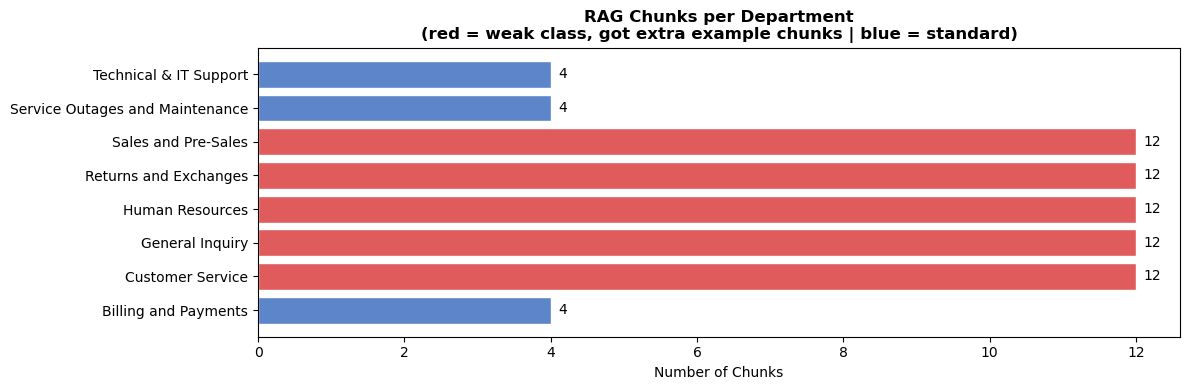


Final chunk counts:
  Customer Service                         12 chunks  F1=0.6  ⚠ weak
  General Inquiry                          12 chunks  F1=0.64  ⚠ weak
  Human Resources                          12 chunks  F1=0.65  ⚠ weak
  Returns and Exchanges                    12 chunks  F1=0.68  ⚠ weak
  Sales and Pre-Sales                      12 chunks  F1=0.71  ⚠ weak
  Billing and Payments                     4 chunks  F1=0.99  
  Service Outages and Maintenance          4 chunks  F1=0.76  
  Technical & IT Support                   4 chunks  F1=0.78  


In [13]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

chunk_counts = Counter(c['dept'] for c in all_chunks)

fig, ax = plt.subplots(figsize=(12, 4))
depts  = list(chunk_counts.keys())
counts = list(chunk_counts.values())
colors = ['#e05c5c' if DEPT_F1.get(d, 1.0) < WEAK_THRESHOLD else '#5c85ca'
          for d in depts]

bars = ax.barh(depts, counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title('RAG Chunks per Department\n'
             '(red = weak class, got extra example chunks | blue = standard)',
             fontweight='bold')
ax.set_xlabel('Number of Chunks')
plt.tight_layout()
plt.savefig('rag_artifacts/chunk_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nFinal chunk counts:')
for dept, count in sorted(chunk_counts.items(), key=lambda x: x[1], reverse=True):
    f1   = DEPT_F1.get(dept, '?')
    weak = '⚠ weak' if isinstance(f1, float) and f1 < WEAK_THRESHOLD else ''
    print(f'  {dept:<40} {count} chunks  F1={f1}  {weak}')